## Import packages

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import integrate
import sys
import os
sys.path.append("../../../../")
from ADFWI.propagator  import *
from ADFWI.model       import *
from ADFWI.view        import *
from ADFWI.utils       import *
from ADFWI.survey      import *
from ADFWI.fwi         import *


project_path = "./examples/elastic/Iso-elastic-Marmousi2-shotWater-recWater/data"
if not os.path.exists(os.path.join(project_path,"model")):
    os.makedirs(os.path.join(project_path,"model"))
if not os.path.exists(os.path.join(project_path,"waveform")):
    os.makedirs(os.path.join(project_path,"waveform"))
if not os.path.exists(os.path.join(project_path,"survey")):
    os.makedirs(os.path.join(project_path,"survey"))
if not os.path.exists(os.path.join(project_path,"inversion")):
    os.makedirs(os.path.join(project_path,"inversion"))

## Define the basic model parameter

In [2]:
device = "cuda:2"
dtype  = torch.float32
ox,oz  = 0,0
nz,nx  = 78,180
dx,dz  = 45, 45
nt,dt  = 1600, 0.003
nabc   = 50
f0     = 3
free_surface = True

## Define the initial velocity model

In [3]:
# Load the Marmousi model dataset from the specified directory.
marmousi_model = load_marmousi_model(in_dir="./examples/datasets/marmousi2_source")
x         = np.linspace(5000, 5000+dx*nx, nx)
z         = np.linspace(0, dz*nz, nz)
vel_model = resample_marmousi_model(x, z, marmousi_model)
vp_true   = vel_model['vp'].T
vs_true   = vel_model['vs'].T
rho_true  = np.power(vp_true, 0.25) * 310
rho_true[:10]  = 1000

smooth_model= get_smooth_marmousi_model(vel_model,gaussian_kernel=4,mask_extra_detph=2)
vp_init     = smooth_model['vp'].T
vs_init     = smooth_model['vs'].T
rho_init    = np.power(vp_init, 0.25) * 310
vp_init[:10]  = vp_true[:10]
vs_init[:10]  = vs_init[:10]
rho_init[:10] = rho_true[:10]


water_layer_mask = np.zeros_like(vp_init)
water_layer_mask[:10] = 1

# processing the water layer
model = IsotropicElasticModel(
                ox,oz,nx,nz,dx,dz,
                vp_init,vs_init,rho_init,
                vp_bound =[vp_true.min(),vp_true.max()],
                vs_bound =[vs_true.min(),vs_true.max()],
                rho_bound=[rho_true.min(),rho_true.max()],
                vp_grad = True,vs_grad = True, rho_grad=False,
                auto_update_rho=True,auto_update_vp=False,
                free_surface=free_surface,
                abc_type="PML",abc_jerjan_alpha=0.007,nabc=nabc,
                water_layer_mask= water_layer_mask,
                device=device,dtype=dtype)

model.save(os.path.join(project_path,"model/init_model.npz"))
print(model.__repr__())

model with parameters ['vp', 'vs', 'rho']:
  Model vp  :  1500.00 -  4229.37 m/s   , requires_grad = True, constrain bound: 1499.9999999999995 - 4775.0557139749435
  Model vs  :    -0.00 -  2407.32 m/s   , requires_grad = True, constrain bound: -3.672910707549285e-38 - 2809.7926509372414
  Model rho :  1000.00 -  2499.95 kg/m^3, requires_grad = False, constrain bound: 1000.0 - 2576.9518543601876
  Model orig: ox =   0.00, oz =   0.00 m
  Model grid: dx =  45.00, dz =  45.00 m
  Model dims: nx =    180, nz =     78
  Model size: 42120
  Free surface: True
  Absorbing layers: 50



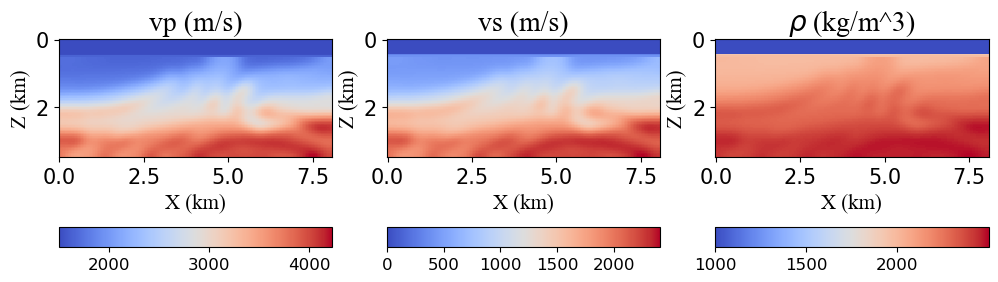

In [4]:
model._plot_vp_vs_rho(figsize=(12,5),wspace=0.2,cbar_pad_fraction=0.18,cbar_height=0.04,cmap='coolwarm',save_path=os.path.join(project_path,"model/init_vp_vs_rho.png"),show=True)

## Define the observed systems: Survey = Source + Receiver

In [5]:
# Define source positions in the model
src_z = np.array([10   for i in range(2,nx-2,5)]) 
src_x = np.array([i    for i in range(2,nx-2,5)])
src_t,src_v = wavelet(nt,dt,f0,amp0=1)
src_v = integrate.cumtrapz(src_v, axis=-1, initial=0) #Integrate
source = Source(nt=nt,dt=dt,f0=f0)
for i in range(len(src_x)):
    source.add_source(src_x=src_x[i],src_z=src_z[i],src_wavelet=src_v,src_type="mt",src_mt=np.array([[1,0,0],[0,1,0],[0,0,1]]))

In [6]:
# Define receiver positions in the model
rcv_z = np.array([10  for i in range(0,nx,1)])
rcv_x = np.array([j   for j in range(0,nx,1)])
receiver = Receiver(nt=nt,dt=dt)
for i in range(len(rcv_x)):
    receiver.add_receiver(rcv_x=rcv_x[i], rcv_z=rcv_z[i], rcv_type="pr")
# survey
survey = Survey(source=source,receiver=receiver)

Survey Information:
Seismic Source:
  Source wavelet: 1600 samples at 3.00 ms
  Source number : 36
  Source types  : ['mt']
  Source x range: 2 - 177 (grids)
  Source z range: 10 - 10 (grids)

Seismic Receiver:
  Receiver data   : 1600 samples at 3.00 ms
  Receiver number : 180
  Receiver types  : ['pr']
  Receiver x range: 0 - 179 (grids)
  Receiver z range: 10 - 10 (grids)



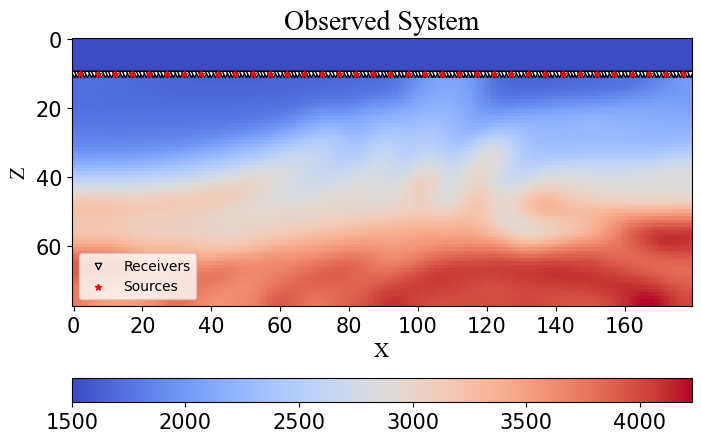

In [7]:
print(survey.__repr__())
survey.plot(model.vp,cmap='coolwarm',save_path=os.path.join(project_path,"survey/observed_system_init.png"),show=True)

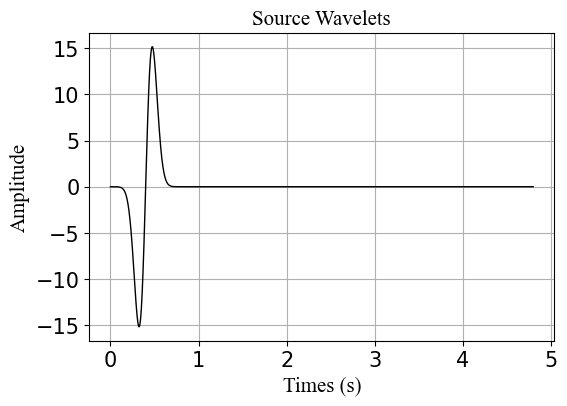

In [8]:
# Plot the wavelet used in the source
source.plot_wavelet(save_path=os.path.join(project_path,"survey/wavelets.png"),show=True)

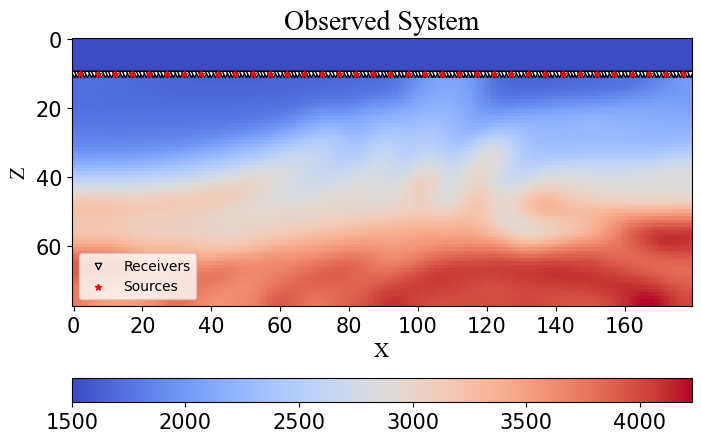

In [9]:
# Plot the survey configuration over the velocity model
survey.plot(model.vp,cmap='coolwarm',save_path=os.path.join(project_path,"survey/observed_system_init.png"))

## Define the propagator

In [10]:
# Initialize the wave propagator using the specified model and survey configuration
F = ElasticPropagator(model,survey,device=device)

In [11]:
# Retrieve the damping array from the propagator and plot it to visualize boundary conditions
if model.abc_type == "PML":
    bcx = F.bcx
    bcz = F.bcz
    title_param = {'family':'Times New Roman','weight':'normal','size': 15}
    plot_bcx_bcz(bcx,bcz,dx=dx,dz=dz,wspace=0.25,title_param=title_param,cbar_height=0.04,cbar_pad_fraction=-0.05,save_path=os.path.join(project_path,"model/boundary_condition_init.png"),show=False)
else:
    damp = F.damp
    plot_damp(damp)

## Load observed datasets

In [12]:
# load data
d_obs = SeismicData(survey)
d_obs.load(os.path.join(project_path,"waveform/obs_data.npz"))
print(d_obs.__repr__())

Seismic Data:
  Source number : 36
  Receiver number : 180
  Time samples : 1600 samples at 3.00 ms



## Inversion

In [13]:
from ADFWI.fwi.misfit import Misfit_waveform_L2
from ADFWI.fwi.regularization import regularization_TV_1order

# Set the number of iterations for the inversion process.
iteration = 10

# optimizer
optimizer   =   torch.optim.AdamW(model.parameters(), lr = 10,betas=(0.9,0.999), weight_decay=1e-4)
scheduler   =   torch.optim.lr_scheduler.StepLR(optimizer,step_size=100,gamma=0.75,last_epoch=-1)

# Setup misfit function
loss_fn = Misfit_waveform_L2(dt=dt)
regularization_fn = regularization_TV_1order(nx,nz,dx,dz,step_size=50,gamma=1,device=device,dtype=dtype)

# gradient processor
grad_mask = np.ones_like(vp_init)
grad_mask[:10] = 0
gradient_processor = GradProcessor(grad_mask=grad_mask,forw_illumination=False)

# Initialize the acoustic full waveform inversion (FWI) object.
fwi = ElasticFWI(propagator=F,
                    model=model,
                    optimizer=optimizer,
                    scheduler=scheduler,
                    loss_fn=loss_fn,
                    regularization_fn=regularization_fn,
                    regularization_weights_x=[0,0,0,0,0,0],
                    regularization_weights_z=[0,0,0,0,0,0],
                    obs_data=d_obs,
                    gradient_processor=gradient_processor,
                    waveform_normalize=True,
                    cache_result=True,
                    save_fig_epoch=50,
                    save_fig_path=os.path.join(project_path,"inversion"),
                    inversion_component=["vx","vz"]
                    )

# Run the forward modeling for the specified number of iterations.
fwi.forward(iteration=iteration,fd_order=4,
                    batch_size=None,checkpoint_segments=2,
                    start_iter=0)

# Retrieve the inversion results: updated velocity and loss values.
iter_vp     = fwi.iter_vp
iter_vs     = fwi.iter_vs
iter_rho    = fwi.iter_rho
iter_loss   = fwi.iter_loss

# Save the iteration results to files for later analysis.
np.savez(os.path.join(project_path,"inversion/iter_vp.npz"),data=np.array(iter_vp))
np.savez(os.path.join(project_path,"inversion/iter_vs.npz"),data=np.array(iter_vs))
np.savez(os.path.join(project_path,"inversion/iter_rho.npz"),data=np.array(iter_rho))
np.savez(os.path.join(project_path,"inversion/iter_loss.npz"),data=np.array(iter_loss))

## visualize the inverted results

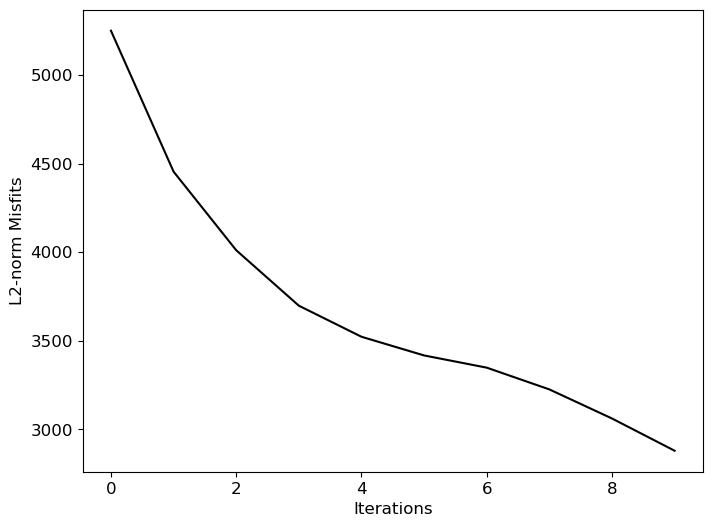

In [14]:
# plot the misfit
plt.figure(figsize=(8,6))
plt.plot(iter_loss,c='k')
plt.xlabel("Iterations", fontsize=12)
plt.ylabel("L2-norm Misfits", fontsize=12)
plt.tick_params(labelsize=12)
plt.savefig(os.path.join(project_path,"inversion/misfit.png"),bbox_inches='tight',dpi=100)
plt.show()

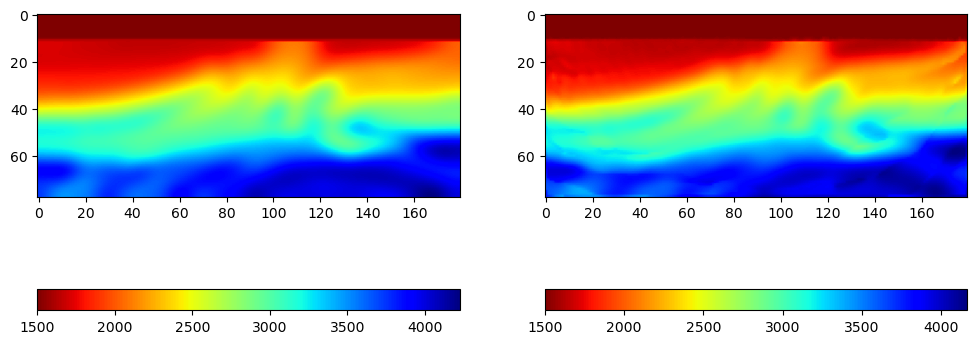

In [15]:
# plot the initial model and inverted resutls
plt.figure(figsize=(12,8))
plt.subplot(121)
plt.imshow(vp_init,cmap='jet_r')
plt.colorbar(orientation='horizontal')
plt.subplot(122)
plt.imshow(iter_vp[-1],cmap='jet_r')
plt.colorbar(orientation='horizontal')
plt.savefig(os.path.join(project_path,"inversion/inverted_vp.png"),bbox_inches='tight',dpi=100)
plt.show()

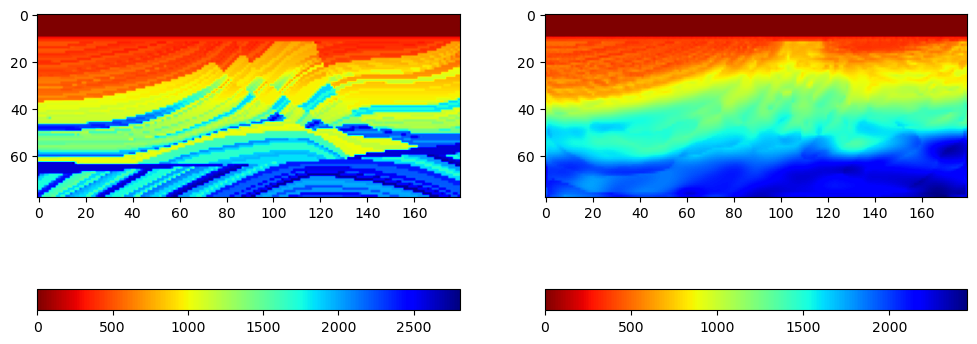

In [16]:
# plot the initial model and inverted resutls
plt.figure(figsize=(12,8))
plt.subplot(121)
plt.imshow(vs_true,cmap='jet_r')
plt.colorbar(orientation='horizontal')
plt.subplot(122)
plt.imshow(iter_vs[-1],cmap='jet_r')
plt.colorbar(orientation='horizontal')
plt.savefig(os.path.join(project_path,"inversion/inverted_vs.png"),bbox_inches='tight',dpi=100)
plt.show()

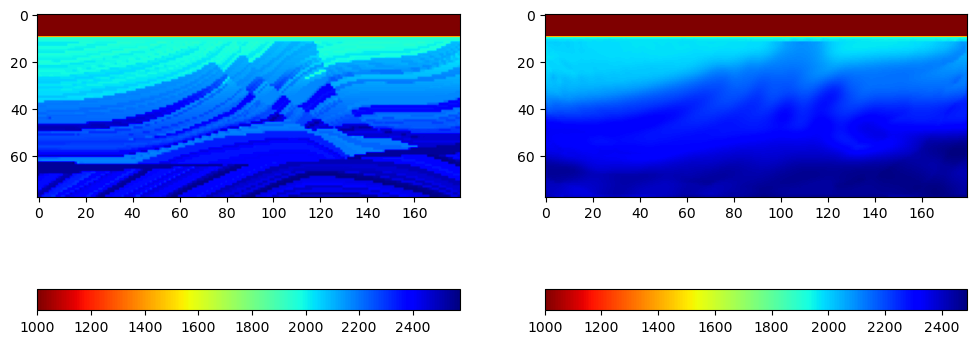

In [17]:
# plot the initial model and inverted resutls
plt.figure(figsize=(12,8))
plt.subplot(121)
plt.imshow(rho_true,cmap='jet_r')
plt.colorbar(orientation='horizontal')
plt.subplot(122)
plt.imshow(iter_rho[-1],cmap='jet_r')
plt.colorbar(orientation='horizontal')
plt.savefig(os.path.join(project_path,"inversion/inverted_rho.png"),bbox_inches='tight',dpi=100)
plt.show()

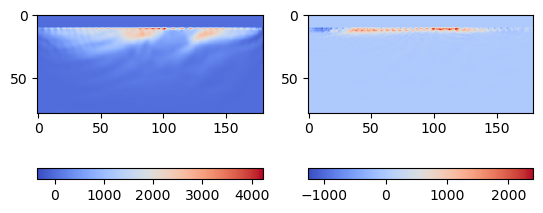

In [21]:
# plot the gradient
plt.figure()
plt.subplot(1,2,1)
plt.imshow(fwi.iter_vp_grad[0],cmap='coolwarm')
plt.colorbar(orientation='horizontal')
plt.subplot(1,2,2)
plt.imshow(fwi.iter_vs_grad[0],cmap='coolwarm')
plt.colorbar(orientation='horizontal')
plt.show()